<a href="https://colab.research.google.com/github/babiologa/Bioestat-stica/blob/main/tarefa11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Tarefa 11**

- Barbara Aimy Baldin
- Dante Gomes Soares de Morais  
- Marina de Oliveira Cappato    


**Observação:** os exemplos numéricos deste notebook são dados simulados, elaborados para representar situações biologicamente plausíveis. Eles não representam uma coleta real de campo ou laboratório.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Semente aleatória para que as simulações possam ser reproduzidas
np.random.seed(42)


 O que é uma variável aleatória?

Em um experimento aleatório, o resultado não pode ser determinado com certeza antes que o experimento seja realizado.

Uma **variável aleatória** é uma variável que associa um valor numérico aos possíveis resultados de um experimento aleatório.

Na Biologia, podemos utilizar variáveis aleatórias para representar, por exemplo:

- o número de sementes que germinam em uma amostra;
- o número de insetos capturados em uma armadilha;
- o número de indivíduos de uma espécie encontrados em uma parcela;
- a massa corporal de um animal;
- o comprimento de uma folha;
- o tempo necessário para uma semente germinar.

### Exemplo biológico

Considere um experimento em que uma semente é observada durante determinado período para verificar se ela germina.

- **Experimento aleatório:** observar uma semente e verificar se ela germina.
- **Variável aleatória:** resultado da germinação.
- **Possíveis valores:** 0 para "não germinou" e 1 para "germinou".

Nesse caso, a variável aleatória representa numericamente o resultado observado.


In [2]:
# Exemplo: resultado de 20 sementes observadas
sementes = np.random.binomial(n=1, p=0.70, size=20)

print("Resultados das sementes:")
print(sementes)
print()
print("Número de sementes que germinaram:", sementes.sum())
print("Número de sementes que não germinaram:", len(sementes) - sementes.sum())


Resultados das sementes:
[1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1]

Número de sementes que germinaram: 14
Número de sementes que não germinaram: 6


### Interpretação

No exemplo, cada posição do vetor representa uma semente. O valor `1` indica germinação e o valor `0` indica ausência de germinação.

Como o experimento foi simulado com probabilidade de germinação de 70%, os resultados podem variar a cada conjunto de observações. A semente individual pode ou não germinar, mesmo que a probabilidade utilizada seja a mesma para todas.


##Variáveis aleatórias discretas e contínuas

As variáveis aleatórias podem ser classificadas, entre outras formas, como **discretas** ou **contínuas**.

### Variável aleatória discreta

Assume valores que podem ser contados, normalmente números inteiros.

Exemplos:

| Variável | Contexto biológico | Por que é discreta? |
|---|---|---|
| Número de insetos capturados | Armadilha em uma noite | É uma contagem e assume valores inteiros |
| Número de sementes germinadas | Amostra de sementes | Não podemos ter uma fração de uma semente germinada |
| Número de colônias bacterianas | Placa de cultura | As colônias são contadas individualmente |

### Variável aleatória contínua

Pode assumir qualquer valor dentro de um intervalo, dependendo da precisão da medição.

Exemplos:

| Variável | Contexto biológico | Por que é contínua? |
|---|---|---|
| Massa corporal | Massa de um animal | Pode assumir diferentes valores dentro de um intervalo |
| Comprimento de uma folha | Morfologia vegetal | Pode ser medido com diferentes valores |
| Temperatura da água | Monitoramento ambiental | Pode assumir valores em um intervalo contínuo |

A principal diferença é que uma variável discreta está relacionada à **contagem**, enquanto uma variável contínua geralmente está relacionada à **medição**.


##Modelo de Bernoulli

O modelo de **Bernoulli** representa um experimento que possui apenas dois resultados possíveis.

Podemos representar esses resultados por:

- `1` = sucesso;
- `0` = fracasso.

A probabilidade de sucesso é representada por `p`, enquanto a probabilidade de fracasso é `1 - p`.

### Exemplo biológico

Vamos considerar a germinação de uma semente.

- **Sucesso:** a semente germina.
- **Fracasso:** a semente não germina.
- **Probabilidade de sucesso:** `p = 0,70`.
- **Variável aleatória:** `X`, em que `X = 1` representa germinação e `X = 0` representa ausência de germinação.

Esse modelo é adequado quando estamos interessados no resultado de **uma única observação**.


In [3]:
# Simulação de um único ensaio de germinação

p_germinacao = 0.70

resultado = np.random.binomial(n=1, p=p_germinacao)

if resultado == 1:
    print("Resultado: a semente germinou.")
else:
    print("Resultado: a semente não germinou.")

print("Valor da variável aleatória X:", resultado)


Resultado: a semente germinou.
Valor da variável aleatória X: 1


### Probabilidades do modelo de Bernoulli

Para uma variável de Bernoulli:

- `P(X = 1) = p`
- `P(X = 0) = 1 - p`

No nosso exemplo:

- `P(X = 1) = 0,70`
- `P(X = 0) = 0,30`


In [4]:
p = 0.70

prob_germinar = p
prob_nao_germinar = 1 - p

tabela_bernoulli = pd.DataFrame({
    "Resultado": ["Germinou", "Não germinou"],
    "Valor de X": [1, 0],
    "Probabilidade": [prob_germinar, prob_nao_germinar]
})

tabela_bernoulli


,Resultado,Valor de X,Probabilidade
0,Germinou,1,0.7
1,Não germinou,0,0.3


### Interpretação biológica

O valor `p = 0,70` representa uma probabilidade de germinação de 70% nas condições consideradas para a simulação. Isso não significa que exatamente 70% de qualquer pequeno grupo de sementes necessariamente germinará. Em diferentes amostras, o número observado pode variar devido à aleatoriedade.

**Conclusão:** o modelo de Bernoulli é útil para representar uma única observação com dois resultados possíveis, como germinar/não germinar ou sobreviver/não sobreviver.


##Modelo Binomial

O modelo **Binomial** pode ser utilizado para representar o número de sucessos em um número fixo de observações.

Para utilizar esse modelo, consideramos:

- um número fixo de observações;
- dois resultados possíveis em cada observação;
- uma probabilidade de sucesso definida;
- independência aproximada entre as observações, quando essa suposição for razoável;
- interesse no número total de sucessos.

### Exemplo biológico

Agora, em vez de observar apenas uma semente, vamos observar **20 sementes**.

Cada semente pode:

- germinar = sucesso;
- não germinar = fracasso.

Vamos considerar `p = 0,70` como a probabilidade de germinação de cada semente.

A variável aleatória `X` será o **número de sementes que germinam entre as 20 observadas**.


In [5]:
n = 20
p = 0.70

# Probabilidade de observar cada possível número de sementes germinadas
valores_x = np.arange(0, n + 1)
probabilidades_binomial = stats.binom.pmf(valores_x, n, p)

tabela_binomial = pd.DataFrame({
    "Número de sementes germinadas (X)": valores_x,
    "P(X = x)": probabilidades_binomial
})

tabela_binomial


,Número de sementes germinadas (X),P(X = x)
0,0,3.486784e-11
1,1,1.627166e-09
2,2,3.606885e-08
3,3,5.049639e-07
4,4,5.007558e-06
5,5,3.738977e-05
6,6,2.181070e-04
7,7,1.017833e-03
8,8,3.859282e-03
9,9,1.200665e-02


### Probabilidade de um resultado específico

Podemos calcular, por exemplo, a probabilidade de exatamente 14 das 20 sementes germinarem.


In [6]:
x = 14

prob_14 = stats.binom.pmf(x, n, p)

print(f"P(X = {x}) = {prob_14:.4f}")
print(f"Em porcentagem: {prob_14 * 100:.2f}%")


P(X = 14) = 0.1916
Em porcentagem: 19.16%


### Valor esperado

Para uma distribuição Binomial, o valor esperado é:

**E(X) = n × p**

Neste exemplo:

**E(X) = 20 × 0,70 = 14**

Portanto, o número esperado de sementes germinadas em muitas repetições desse experimento é 14 por grupo de 20 sementes.


In [7]:
valor_esperado = n * p

print("Número esperado de sementes germinadas:", valor_esperado)


Número esperado de sementes germinadas: 14.0


### Distribuição Binomial

O gráfico abaixo mostra a probabilidade associada a cada possível número de sementes germinadas.


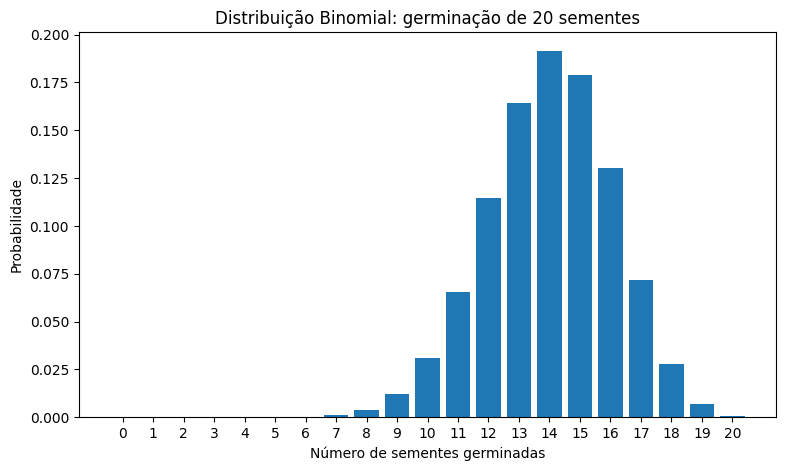

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(valores_x, probabilidades_binomial)
plt.xlabel("Número de sementes germinadas")
plt.ylabel("Probabilidade")
plt.title("Distribuição Binomial: germinação de 20 sementes")
plt.xticks(valores_x)
plt.show()


### Simulação de várias amostras

Agora vamos simular 1.000 grupos, cada um contendo 20 sementes, usando a mesma probabilidade de germinação.


In [9]:
n_amostras = 1000

simulacoes_binomial = np.random.binomial(
    n=n,
    p=p,
    size=n_amostras
)

print("Média observada nas 1.000 simulações:",
      simulacoes_binomial.mean())

print("Valor esperado:", valor_esperado)


Média observada nas 1.000 simulações: 14.038
Valor esperado: 14.0


### Interpretação biológica

Nas diferentes amostras simuladas, o número de sementes germinadas não é sempre igual. Mesmo com a mesma probabilidade de germinação, algumas amostras terão mais e outras menos sementes germinadas.

Quando o número de repetições aumenta, a média dos resultados simulados tende a se aproximar do valor esperado de 14 sementes germinadas por grupo.

**Conclusão:** o modelo Binomial é apropriado para situações em que contamos o número de sucessos em um número fixo de ensaios, como o número de sementes germinadas em uma amostra de tamanho definido.

Uma limitação importante é que a independência entre sementes pode não ser totalmente realista em uma situação biológica. Condições ambientais, qualidade das sementes ou características compartilhadas podem fazer com que os resultados não sejam completamente independentes.


##Modelo de Poisson

O modelo de **Poisson** é utilizado para representar a contagem de eventos em um intervalo definido de tempo, espaço, área, volume ou outra unidade de observação.

Um parâmetro importante desse modelo é `λ` (lambda), que representa a **taxa média de ocorrência do evento** no intervalo considerado.

### Exemplo biológico

Vamos considerar o monitoramento de insetos utilizando uma armadilha.

A unidade de observação será:

**1 armadilha durante 1 noite.**

Suponha que, em condições semelhantes de monitoramento, a média esperada seja de **4 insetos capturados por armadilha por noite**.

Assim:

**λ = 4 insetos/noite**

A variável aleatória `X` representa o número de insetos capturados em uma noite por uma armadilha.


In [10]:
lambda_insetos = 4

valores_poisson = np.arange(0, 16)
probabilidades_poisson = stats.poisson.pmf(valores_poisson, lambda_insetos)

tabela_poisson = pd.DataFrame({
    "Número de insetos capturados (X)": valores_poisson,
    "P(X = x)": probabilidades_poisson
})

tabela_poisson


,Número de insetos capturados (X),P(X = x)
0,0,0.018316
1,1,0.073263
2,2,0.146525
3,3,0.195367
4,4,0.195367
5,5,0.156293
6,6,0.104196
7,7,0.059540
8,8,0.029770
9,9,0.013231


### Probabilidade de um número específico de insetos

Podemos calcular, por exemplo, a probabilidade de uma armadilha capturar exatamente 6 insetos durante uma noite.


In [11]:
x = 6

prob_6 = stats.poisson.pmf(x, lambda_insetos)

print(f"P(X = {x}) = {prob_6:.4f}")
print(f"Em porcentagem: {prob_6 * 100:.2f}%")


P(X = 6) = 0.1042
Em porcentagem: 10.42%


### Valor esperado

Na distribuição de Poisson, o valor esperado é igual ao parâmetro `λ`.

Neste exemplo:

**E(X) = λ = 4**

Portanto, espera-se uma média de aproximadamente 4 insetos capturados por armadilha em uma noite, considerando as condições utilizadas na simulação.


In [12]:
print("Taxa média de captura (lambda):", lambda_insetos)
print("Número esperado de insetos por noite:", lambda_insetos)


Taxa média de captura (lambda): 4
Número esperado de insetos por noite: 4


### Distribuição de Poisson

O gráfico mostra as probabilidades dos diferentes números de insetos que podem ser capturados em uma noite.


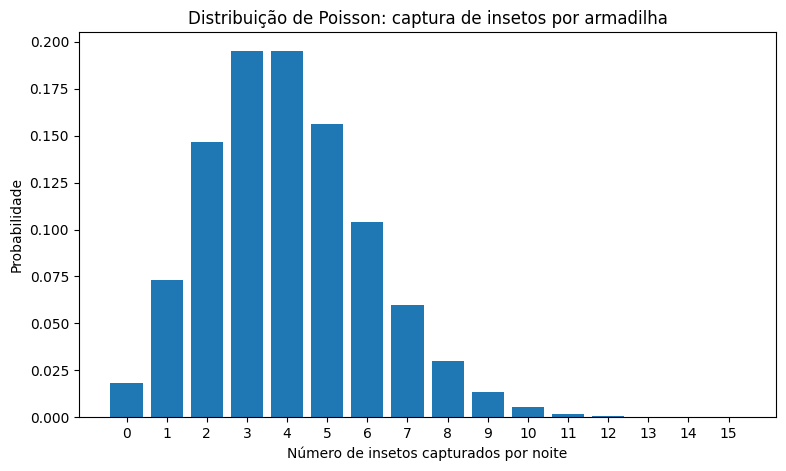

In [13]:
plt.figure(figsize=(9, 5))
plt.bar(valores_poisson, probabilidades_poisson)
plt.xlabel("Número de insetos capturados por noite")
plt.ylabel("Probabilidade")
plt.title("Distribuição de Poisson: captura de insetos por armadilha")
plt.xticks(valores_poisson)
plt.show()


### Simulação de várias noites

Vamos simular 1.000 noites de monitoramento, considerando uma armadilha e uma taxa média de 4 insetos por noite.


In [14]:
n_noites = 1000

simulacoes_poisson = np.random.poisson(
    lam=lambda_insetos,
    size=n_noites
)

print("Média observada nas 1.000 noites:",
      simulacoes_poisson.mean())

print("Taxa média utilizada na simulação:",
      lambda_insetos)


Média observada nas 1.000 noites: 3.964
Taxa média utilizada na simulação: 4


### Interpretação biológica

Os resultados representam diferentes números de insetos capturados em noites distintas. Mesmo que a taxa média seja de 4 insetos por noite, uma noite pode apresentar 2, 5, 7 ou outro número de indivíduos.

A unidade de observação é importante: neste exemplo, `λ = 4` significa **4 insetos por armadilha por noite**. Se a unidade de observação fosse alterada, por exemplo, para uma semana ou para várias armadilhas, a interpretação do parâmetro também teria que ser alterada.

**Conclusão:** o modelo de Poisson pode ser utilizado para estudar contagens de eventos em uma unidade definida, como o número de insetos capturados por armadilha por noite.

A adequação do modelo depende das características do sistema biológico. Por exemplo, diferenças muito grandes entre locais, horários ou condições ambientais podem fazer com que a taxa de ocorrência não seja constante.


##Comparação entre Bernoulli, Binomial e Poisson

Os três modelos estão relacionados, mas representam situações diferentes.

| Modelo | Fenômeno representado | Valores possíveis | Parâmetros principais | Exemplo em Biologia |
|---|---|---|---|---|
| Bernoulli | Um único ensaio com dois resultados | 0 ou 1 | `p` | Uma semente germina ou não |
| Binomial | Número de sucessos em um número fixo de ensaios | 0 até `n` | `n` e `p` | Número de sementes germinadas em 20 sementes |
| Poisson | Número de eventos em uma unidade definida | 0, 1, 2, 3, ... | `λ` | Número de insetos capturados por armadilha por noite |

Uma forma simples de diferenciar os modelos é perguntar:

**Bernoulli:** aconteceu ou não aconteceu em uma observação?

**Binomial:** quantas vezes o evento aconteceu em um número fixo de observações?

**Poisson:** quantos eventos ocorreram em uma determinada unidade de tempo, espaço, área, volume ou outra unidade de observação?


##Comparação visual das distribuições

Podemos visualizar as três distribuições utilizadas nos exemplos.

Para facilitar a comparação, cada modelo será representado de acordo com seu próprio contexto:

- Bernoulli: uma semente germina ou não;
- Binomial: número de sementes germinadas em 20 sementes;
- Poisson: número de insetos capturados por armadilha por noite.


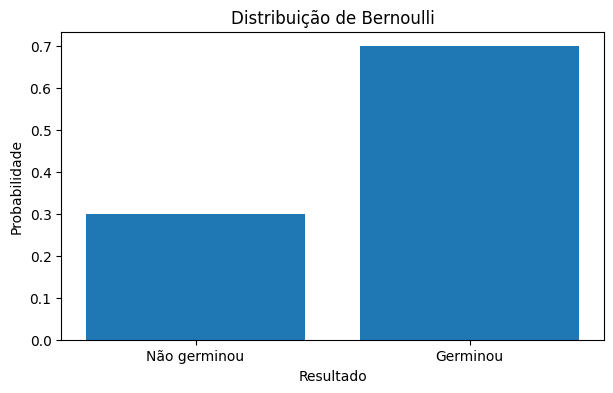

In [15]:
# Bernoulli
x_bernoulli = np.array([0, 1])
p_bernoulli = stats.bernoulli.pmf(x_bernoulli, 0.70)

plt.figure(figsize=(7, 4))
plt.bar(x_bernoulli, p_bernoulli)
plt.xlabel("Resultado")
plt.ylabel("Probabilidade")
plt.title("Distribuição de Bernoulli")
plt.xticks([0, 1], ["Não germinou", "Germinou"])
plt.show()


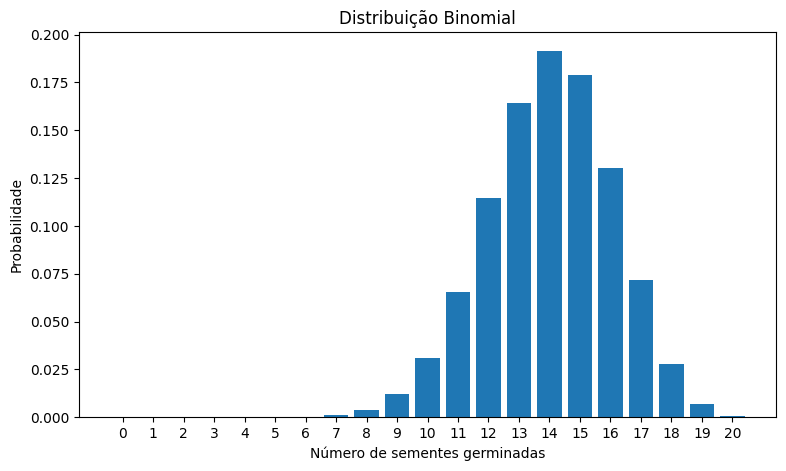

In [16]:
# Binomial
plt.figure(figsize=(9, 5))
plt.bar(valores_x, probabilidades_binomial)
plt.xlabel("Número de sementes germinadas")
plt.ylabel("Probabilidade")
plt.title("Distribuição Binomial")
plt.xticks(valores_x)
plt.show()


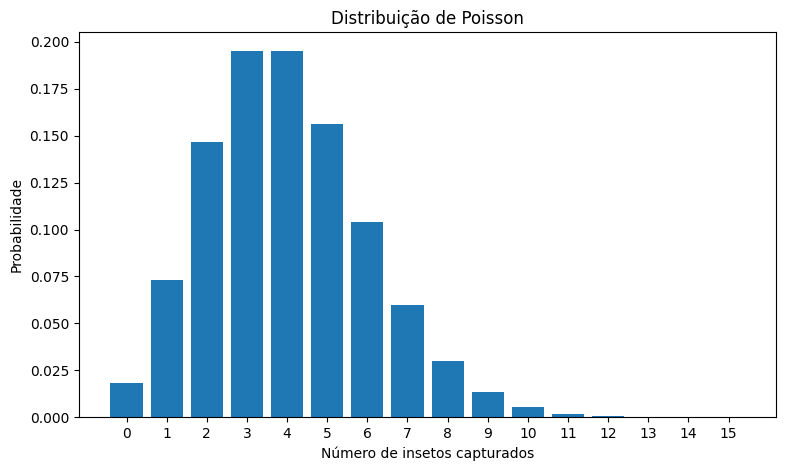

In [17]:
# Poisson
plt.figure(figsize=(9, 5))
plt.bar(valores_poisson, probabilidades_poisson)
plt.xlabel("Número de insetos capturados")
plt.ylabel("Probabilidade")
plt.title("Distribuição de Poisson")
plt.xticks(valores_poisson)
plt.show()


##Interpretação geral

Os três modelos permitem representar diferentes formas de ocorrência de fenômenos biológicos.

O **Bernoulli** é adequado para uma única observação com dois resultados possíveis. No exemplo, a semente pode germinar ou não germinar.

O **Binomial** amplia essa ideia para um número fixo de observações. Assim, podemos estudar quantas sementes germinam dentro de uma amostra com tamanho definido.

O **Poisson** é diferente porque está relacionado à contagem de eventos dentro de uma unidade de observação, como tempo, área ou espaço. No exemplo, contamos quantos insetos são capturados por armadilha em uma noite.

É importante lembrar que um modelo probabilístico é uma representação simplificada de uma situação real. Antes de utilizá-lo em um estudo biológico, é necessário verificar se suas suposições são razoáveis para os dados e para o processo estudado.


##Conclusão

A utilização de variáveis aleatórias e modelos probabilísticos permite representar matematicamente situações em que existe variabilidade e incerteza, algo frequente em estudos biológicos.

Neste notebook, vimos que:

- uma variável aleatória associa valores numéricos aos resultados de um experimento aleatório;
- variáveis discretas estão relacionadas principalmente a contagens;
- variáveis contínuas estão relacionadas principalmente a medições;
- o modelo de Bernoulli representa um único experimento com dois resultados;
- o modelo Binomial representa o número de sucessos em um número fixo de ensaios;
- o modelo de Poisson representa a contagem de eventos em uma unidade definida;
- a interpretação biológica depende das características do fenômeno estudado e das suposições do modelo.

Os exemplos utilizados foram simulados para demonstrar os modelos. Em uma aplicação real, os parâmetros deveriam ser definidos a partir de dados observados ou de informações justificadas para o sistema biológico estudado.


Referências e fontes

- MAGALHÃES, Marcos Nascimento; LIMA, Antonio Carlos Pedroso de. *Noções de Probabilidade e Estatística*.
- MEYER, Paul L. *Probabilidade: Aplicações à Estatística*.
- MONTGOMERY, Douglas C.; RUNGER, George C. *Estatística Aplicada e Probabilidade para Engenheiros*.
- ROSS, Sheldon. *A First Course in Probability*.
- ZAR, Jerrold H. *Biostatistical Analysis*.
- SOKAL, Robert R.; ROHLF, F. James. *Biometry: The Principles and Practice of Statistics in Biological Research*.

### Bibliotecas utilizadas

- NumPy
- pandas
- Matplotlib
- SciPy

### Dados

Os dados apresentados neste notebook são **simulados**. Não foram utilizados conjuntos de dados externos.
